In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from rich.console import Console
from rich.table import Table
 
PROC_DIR = Path("../data/processed")
console  = Console()
 
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)
print("✓ Imports done")

✓ Imports done


In [2]:
train = pd.read_parquet(PROC_DIR / "train.parquet")
val   = pd.read_parquet(PROC_DIR / "val.parquet")
test  = pd.read_parquet(PROC_DIR / "test.parquet")
users = pd.read_parquet(PROC_DIR / "user_features.parquet")
items = pd.read_parquet(PROC_DIR / "item_features.parquet")
 
print(f"Train : {len(train):>12,} rows")
print(f"Val   : {len(val):>12,} rows")
print(f"Test  : {len(test):>12,} rows")
print(f"Users : {len(users):>12,} unique")
print(f"Items : {len(items):>12,} unique")
print(f"\nTrain columns: {list(train.columns)}")

Train :   20,000,076 rows
Val   :    2,500,009 rows
Test  :    2,500,010 rows
Users :      137,883 unique
Items :       34,461 unique

Train columns: ['userId', 'movieId', 'rating', 'timestamp', 'label', 'hour_of_day', 'day_of_week', 'month', 'user_idx', 'movie_idx']


Positive rate (rating ≥ 4.0): 49.9%
Negative rate (rating < 4.0): 50.1%

This means for every positive, we have 1.0x more negatives

Interview answer: mild imbalance — no oversampling needed.
We handle it via in-batch negative sampling in the Two-Tower model.


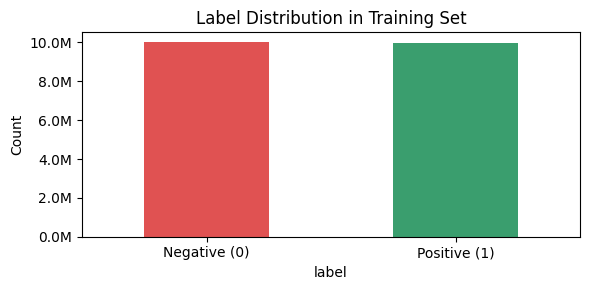

In [3]:
# Interview Q: "What's your positive rate? How does class imbalance affect training?"
pos_rate = train["label"].mean()
print(f"Positive rate (rating ≥ 4.0): {pos_rate:.1%}")
print(f"Negative rate (rating < 4.0): {1 - pos_rate:.1%}")
print(f"\nThis means for every positive, we have "
      f"{(1-pos_rate)/pos_rate:.1f}x more negatives")
print(f"\nInterview answer: mild imbalance — no oversampling needed.")
print(f"We handle it via in-batch negative sampling in the Two-Tower model.")
 
fig, ax = plt.subplots(figsize=(6, 3))
train["label"].value_counts().plot(kind="bar", ax=ax, color=["#e05252","#3a9e6e"])
ax.set_xticklabels(["Negative (0)", "Positive (1)"], rotation=0)
ax.set_title("Label Distribution in Training Set")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../data/processed/label_dist.png", dpi=120)
plt.show()
 

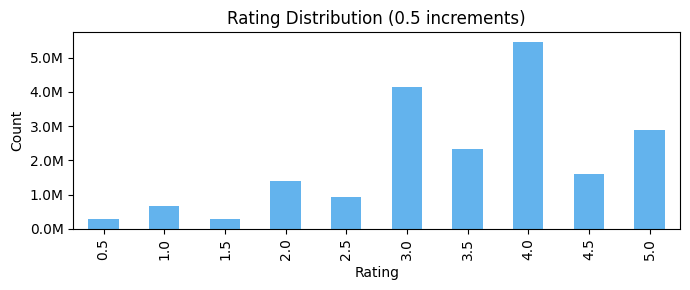

  Rating ≥ 3.0: 82.3%
  Rating ≥ 3.5: 61.5%
  Rating ≥ 4.0: 49.9%
  Rating ≥ 4.5: 22.6%


In [4]:
# Why this matters: justifies our 4.0 threshold choice
fig, ax = plt.subplots(figsize=(7, 3))
train["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#63b3ed")
ax.set_title("Rating Distribution (0.5 increments)")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../data/processed/rating_dist.png", dpi=120)
plt.show()
 
# Key stat: what % of ratings are 4.0+?
for threshold in [3.0, 3.5, 4.0, 4.5]:
    pct = (train["rating"] >= threshold).mean()
    print(f"  Rating ≥ {threshold}: {pct:.1%}")
 

User activity stats:
count   137883.000
mean       145.051
std        236.363
min          1.000
25%         35.000
50%         68.000
75%        154.000
max      12097.000


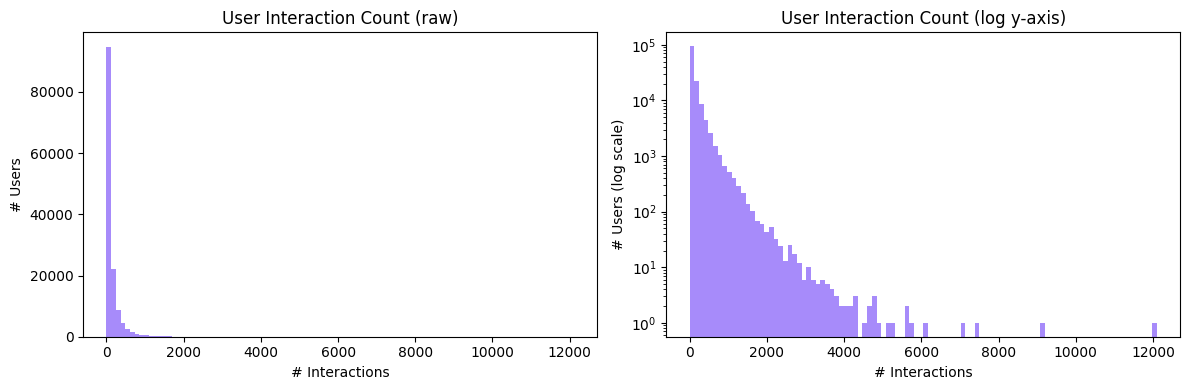


Top 10% of users have ≥ 335 interactions
Top  1% of users have ≥ 1134 interactions

Interview answer: Long-tail distribution is universal in recommenders.
Cold-start users (< 5 interactions) need special handling — popularity fallback.
Cold-start users (< 5 ratings): 0.0% of all users


In [5]:
# Interview Q: "How do you handle power users dominating your training signal?"
print("User activity stats:")
print(users["n_interactions"].describe().to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Left: raw distribution (shows long tail)
axes[0].hist(users["n_interactions"], bins=100, color="#a78bfa", edgecolor="none")
axes[0].set_title("User Interaction Count (raw)")
axes[0].set_xlabel("# Interactions")
axes[0].set_ylabel("# Users")
 
# Right: log scale reveals the long tail structure clearly
axes[1].hist(users["n_interactions"], bins=100, color="#a78bfa",
             edgecolor="none", log=True)
axes[1].set_title("User Interaction Count (log y-axis)")
axes[1].set_xlabel("# Interactions")
axes[1].set_ylabel("# Users (log scale)")
 
plt.tight_layout()
plt.savefig("../data/processed/user_activity.png", dpi=120)
plt.show()
 
# Power user analysis
p90 = users["n_interactions"].quantile(0.90)
p99 = users["n_interactions"].quantile(0.99)
print(f"\nTop 10% of users have ≥ {p90:.0f} interactions")
print(f"Top  1% of users have ≥ {p99:.0f} interactions")
print(f"\nInterview answer: Long-tail distribution is universal in recommenders.")
print(f"Cold-start users (< 5 interactions) need special handling — popularity fallback.")
 
cold_start = (users["n_interactions"] < 5).mean()
print(f"Cold-start users (< 5 ratings): {cold_start:.1%} of all users")

Item popularity stats:
count   34461.000
mean      580.368
std      2684.587
min         1.000
25%         2.000
50%         9.000
75%       106.000
max     67782.000


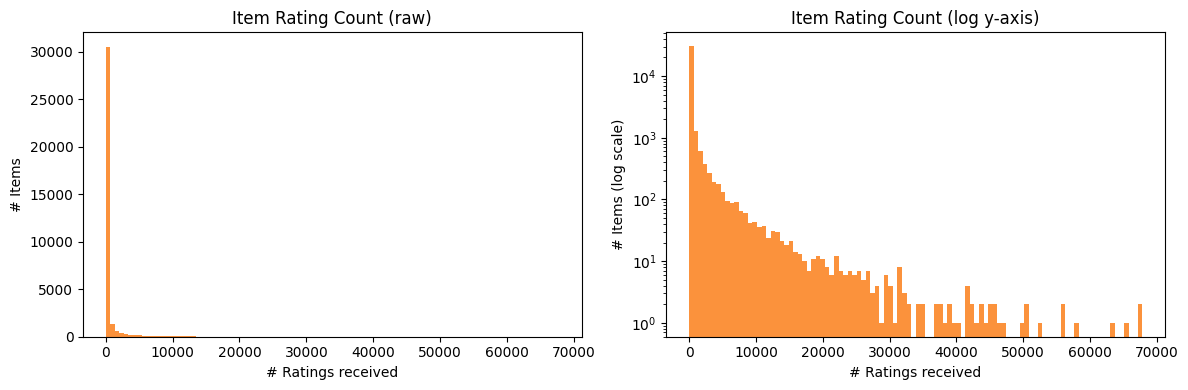


Items with < 10 ratings: 50.4% — the long tail
These are the 'cold-start items' — Two-Tower handles via content features


In [6]:
# Interview Q: "How do you prevent your model from only recommending popular items?"
print("Item popularity stats:")
print(items["n_ratings"].describe().to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].hist(items["n_ratings"], bins=100, color="#fb923c", edgecolor="none")
axes[0].set_title("Item Rating Count (raw)")
axes[0].set_xlabel("# Ratings received")
axes[0].set_ylabel("# Items")
 
axes[1].hist(items["n_ratings"], bins=100, color="#fb923c",
             edgecolor="none", log=True)
axes[1].set_title("Item Rating Count (log y-axis)")
axes[1].set_xlabel("# Ratings received")
axes[1].set_ylabel("# Items (log scale)")
 
plt.tight_layout()
plt.savefig("../data/processed/item_popularity.png", dpi=120)
plt.show()
 
# Long-tail: most items are rarely rated
rarely_rated = (items["n_ratings"] < 10).mean()
print(f"\nItems with < 10 ratings: {rarely_rated:.1%} — the long tail")
print(f"These are the 'cold-start items' — Two-Tower handles via content features")

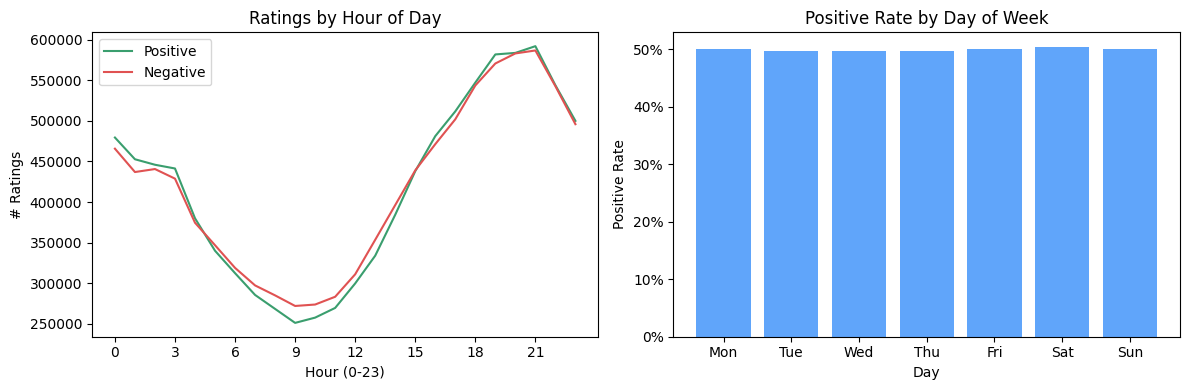

Interview insight: temporal patterns justify including hour_of_day
and day_of_week as context features in the Two-Tower model.


In [7]:
# Why this matters: proves why we need time-based features in the model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Hour of day — is there a peak viewing time?
hour_pos = train[train["label"]==1].groupby("hour_of_day").size()
hour_neg = train[train["label"]==0].groupby("hour_of_day").size()
 
axes[0].plot(hour_pos.index, hour_pos.values, color="#3a9e6e", label="Positive")
axes[0].plot(hour_neg.index, hour_neg.values, color="#e05252", label="Negative")
axes[0].set_title("Ratings by Hour of Day")
axes[0].set_xlabel("Hour (0-23)")
axes[0].set_ylabel("# Ratings")
axes[0].legend()
axes[0].set_xticks(range(0, 24, 3))
 
# Day of week
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
day_counts = train.groupby("day_of_week")["label"].mean()
axes[1].bar(day_labels, day_counts.values, color="#60a5fa")
axes[1].set_title("Positive Rate by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Positive Rate")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
 
plt.tight_layout()
plt.savefig("../data/processed/temporal_patterns.png", dpi=120)
plt.show()
 
print("Interview insight: temporal patterns justify including hour_of_day")
print("and day_of_week as context features in the Two-Tower model.")

In [8]:
# Interview Q: "How sparse is your interaction matrix?"
import json
user2idx  = json.loads((PROC_DIR / "user2idx.json").read_text())
movie2idx = json.loads((PROC_DIR / "movie2idx.json").read_text())
 
n_users   = len(user2idx)
n_items   = len(movie2idx)
n_train   = len(train)
 
possible_interactions = n_users * n_items
sparsity = 1 - (n_train / possible_interactions)
 
print(f"Matrix dimensions : {n_users:,} users × {n_items:,} items")
print(f"Possible pairs    : {possible_interactions:,.0f}")
print(f"Observed (train)  : {n_train:,}")
print(f"Sparsity          : {sparsity:.4%}")
print(f"\nInterview answer: {sparsity:.2%} sparse.")
print(f"This is why collaborative filtering alone fails —")
print(f"most user-item pairs are never observed.")
print(f"Two-Tower + content features bridges this gap.")

Matrix dimensions : 162,541 users × 59,047 items
Possible pairs    : 9,597,558,427
Observed (train)  : 20,000,076
Sparsity          : 99.7916%

Interview answer: 99.79% sparse.
This is why collaborative filtering alone fails —
most user-item pairs are never observed.
Two-Tower + content features bridges this gap.


In [9]:
print("\n" + "="*55)
print("  KEY NUMBERS — MEMORISE THESE FOR INTERVIEWS")
print("="*55)
stats = [
    ("Total ratings",          f"{len(train)+len(val)+len(test):,}"),
    ("Unique users",           f"{n_users:,}"),
    ("Unique movies",          f"{n_items:,}"),
    ("Train interactions",     f"{len(train):,}"),
    ("Positive rate",          f"{train['label'].mean():.1%}"),
    ("Matrix sparsity",        f"{sparsity:.3%}"),
    ("Cold-start users",       f"{cold_start:.1%} have < 5 ratings"),
    ("Cold-start items",       f"{rarely_rated:.1%} have < 10 ratings"),
    ("Train / Val / Test",     "80% / 10% / 10%"),
    ("Split strategy",         "Temporal (by timestamp)"),
]
for label, value in stats:
    print(f"  {label:<25} {value}")
print("="*55)
 


  KEY NUMBERS — MEMORISE THESE FOR INTERVIEWS
  Total ratings             25,000,095
  Unique users              162,541
  Unique movies             59,047
  Train interactions        20,000,076
  Positive rate             49.9%
  Matrix sparsity           99.792%
  Cold-start users          0.0% have < 5 ratings
  Cold-start items          50.4% have < 10 ratings
  Train / Val / Test        80% / 10% / 10%
  Split strategy            Temporal (by timestamp)
